# Human Development Index Predictor

This notebook contains the complete machine learning workflow to preprocess, analyze, and train a model to predict the Human Development Index (HDI) of countries based on their health, education, and income indicators.

## 1. Data Preprocessing

We load the raw HDI dataset, select key development indicators, and impute missing values.

In [7]:
import pandas as pd
from pathlib import Path

# Load Dataset
dataset_dir = Path('../Dataset')
df = pd.read_csv(dataset_dir / 'HDI.csv')

selected_columns = [
    'Country',
    'Life Expectancy at Birth (2021)',
    'Expected Years of Schooling (2021)',
    'Mean Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)',
    'Human Development Index (2021)'
]

clean_df = df[selected_columns].copy()

# Fill missing values (CoW compliant)
for col in clean_df.columns:
    if pd.api.types.is_numeric_dtype(clean_df[col]):
        clean_df[col] = clean_df[col].fillna(clean_df[col].mean())
    else:
        clean_df[col] = clean_df[col].fillna(clean_df[col].mode()[0])

clean_df.to_csv(dataset_dir / 'HDI_Cleaned.csv', index=False)
print('Cleaned dataset saved successfully!')
print('Dataset shape:', clean_df.shape)
clean_df.head()

Cleaned dataset saved successfully!
Dataset shape: (195, 6)


,Country,Life Expectancy at Birth (2021),Expected Years of Schooling (2021),Mean Years of Schooling (2021),Gross National Income Per Capita (2021),Human Development Index (2021)
0,Afghanistan,61.9824,10.263844,2.985070,1824.190915,0.478
1,Angola,61.6434,12.172100,5.417391,5465.617791,0.586
2,Albania,76.4626,14.448000,11.286455,14131.110390,0.796
3,Andorra,80.3684,13.300239,10.555120,51166.626610,0.858
4,United Arab Emirates,78.7104,15.717690,12.694030,62573.591810,0.911


## 2. Exploratory Data Analysis (EDA)

Visualize relationships and distribution of indicators using Matplotlib and Seaborn.

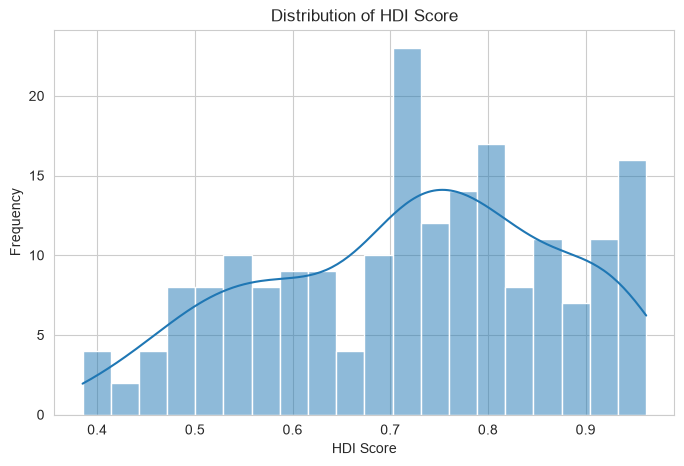

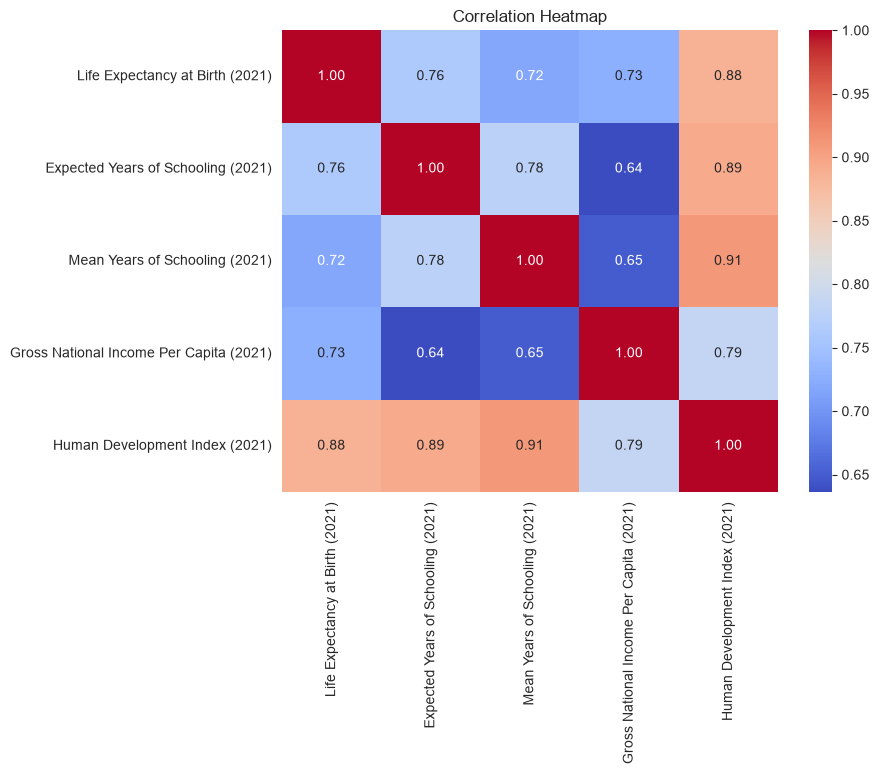

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_style('whitegrid')

# 1. Distribution Plot of HDI
plt.figure(figsize=(8, 5))
sns.histplot(data=clean_df, x='Human Development Index (2021)', bins=20, kde=True)
plt.title('Distribution of HDI Score')
plt.xlabel('HDI Score')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = clean_df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

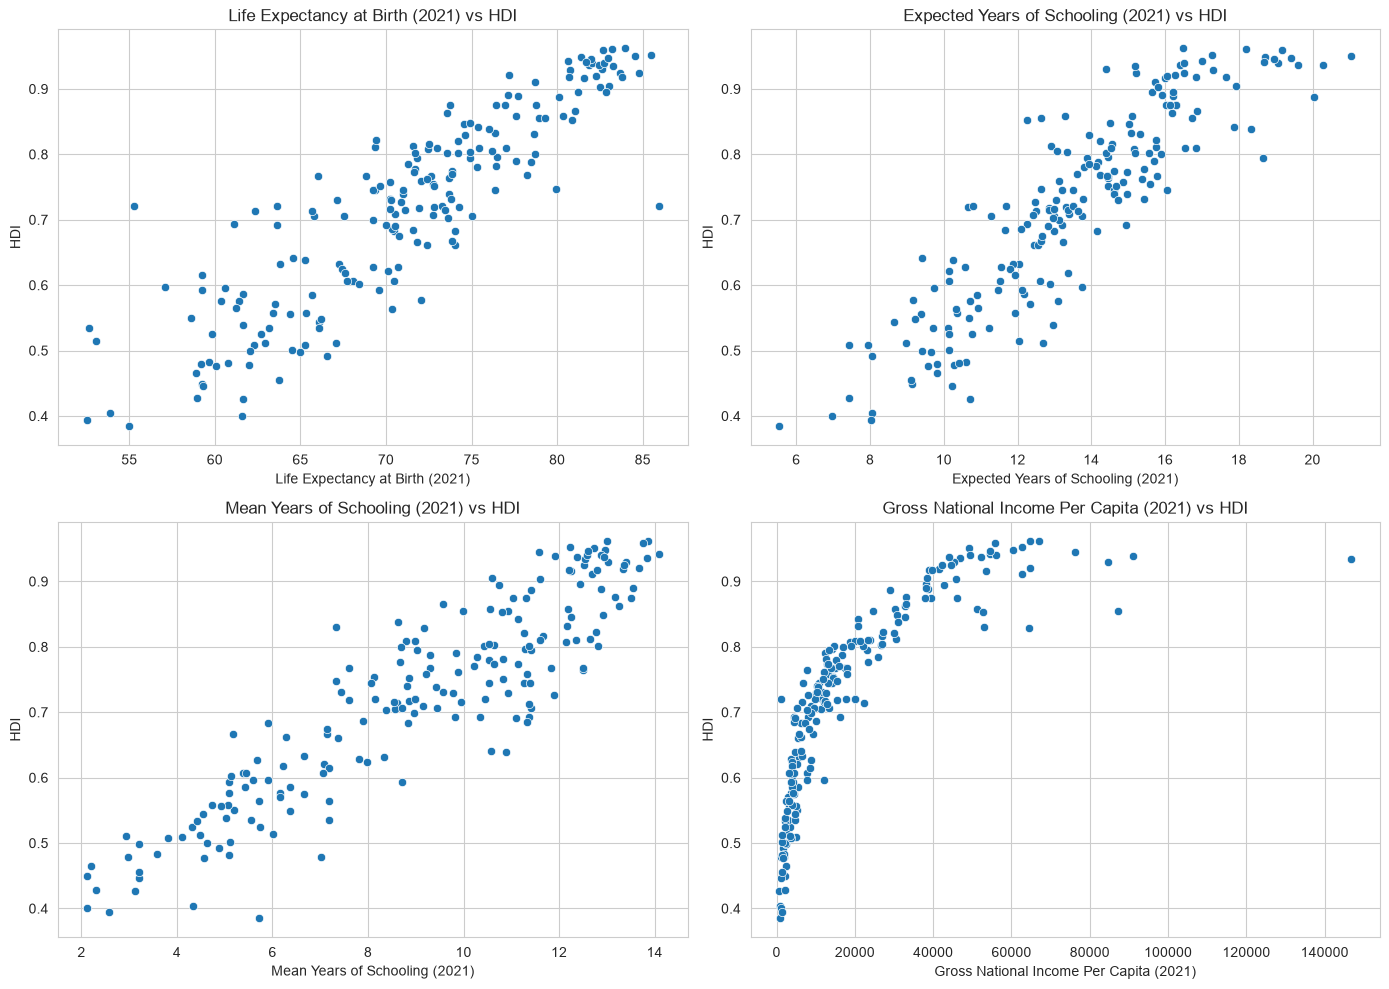

In [9]:
# 3. Scatter Plots of Features vs HDI
features = [
    'Life Expectancy at Birth (2021)',
    'Expected Years of Schooling (2021)',
    'Mean Years of Schooling (2021)',
    'Gross National Income Per Capita (2021)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.scatterplot(data=clean_df, x=feature, y='Human Development Index (2021)', ax=axes[idx])
    axes[idx].set_title(f'{feature} vs HDI')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('HDI')

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Preprocessing

Select features, encode the country labels, and split datasets into train/test sets.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_fe = clean_df.copy()
encoder = LabelEncoder()
df_fe['Country'] = encoder.fit_transform(df_fe['Country'])

X = df_fe[features]
y = df_fe['Human Development Index (2021)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print('Train-test split complete!')
print(f'Training shape: {X_train.shape}')
print(f'Testing shape: {X_test.shape}')

Train-test split complete!
Training shape: (156, 4)
Testing shape: (39, 4)


## 4. Model Training & Evaluation

Train a Linear Regression model to predict the HDI score and analyze performance.

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('Model Performance Summary')
print('-' * 30)
print(f'R-squared Score      : {r2:.4f}')
print(f'Mean Absolute Error  : {mae:.4f}')
print(f'Root Mean Sq. Error  : {rmse:.4f}')

# Save the model directly into Flask directory
flask_dir = Path('../Flask')
model_file = flask_dir / 'HDI.pkl'

with open(model_file, 'wb') as file:
    pickle.dump(model, file)

print(f'Model saved successfully to: {model_file.resolve()}')

Model Performance Summary
------------------------------
R-squared Score      : 0.9582
Mean Absolute Error  : 0.0216
Root Mean Sq. Error  : 0.0326
Model saved successfully to: C:\Users\Sandeep\OneDrive\Desktop\ML - 0027 - Human Development Index\Flask\HDI.pkl


## 5. Model Validation

Verify the model loading and test single prediction outputs.

In [12]:
# Load model
with open(model_file, 'rb') as file:
    loaded_model = pickle.load(file)

# Verify prediction with Australia's metrics
# Life Expectancy=84.5, Expected Schooling=21.05, Mean Schooling=12.7, GNI=49238
sample_input = [[84.5, 21.05, 12.7, 49238]]
prediction = loaded_model.predict(sample_input)

print(f'Predicted HDI for Australia: {prediction[0]:.3f}')
print(f'Actual HDI (2021) for Australia: 0.951')

Predicted HDI for Australia: 1.003
Actual HDI (2021) for Australia: 0.951


C:\Users\Sandeep\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
